In [1]:
# Clone repository

import os

os.chdir("/content")

!rm -rf Deepfake-Detection-KYC

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 174 (delta 90), reused 106 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 3.16 MiB | 12.74 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/Deepfake-Detection-KYC


In [2]:
from pathlib import Path

print(Path.cwd())

!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [3]:
!pip install -q kaggle pandas numpy matplotlib tqdm opencv-python==4.10.0.84

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 18.7 MB/s eta 0:00:00


In [5]:
import os
from getpass import getpass

print("Configure Kaggle")

os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass("API Token: ")

print("Kaggle configured")

Configure Kaggle
Username: tanvi2609
API Token: ··········
Kaggle configured


In [6]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [7]:
!kaggle datasets list -s faceforensics


ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4873         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          56988        107  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000           9029         26  0.3125  

In [8]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [01:49<00:00, 163MB/s]



In [9]:
!ls -lh

total 17G
drwxr-xr-x 6 root root 4.0K Aug  4 11:56 data
drwxr-xr-x 2 root root 4.0K Aug  4 11:56 docs
-rw-r--r-- 1 root root  218 Aug  4 11:56 environment.yml
-rw-r--r-- 1 root root  17G Dec  7  2024 ff-c23.zip
drwxr-xr-x 2 root root 4.0K Aug  4 11:56 notebooks
drwxr-xr-x 6 root root 4.0K Aug  4 11:56 outputs
drwxr-xr-x 2 root root 4.0K Aug  4 11:56 presentations
-rw-r--r-- 1 root root  960 Aug  4 11:56 README.md
drwxr-xr-x 2 root root 4.0K Aug  4 11:56 reports
-rw-r--r-- 1 root root   81 Aug  4 11:56 requirements.txt
drwxr-xr-x 8 root root 4.0K Aug  4 11:56 src


In [10]:
!mkdir -p data/raw

In [11]:
!unzip -q ff-c23.zip -d data/raw/

In [12]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/NeuralTextures
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/csv


In [13]:
%cd /content/Deepfake-Detection-KYC

!find data/raw -maxdepth 2 -type d

/content/Deepfake-Detection-KYC
data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/NeuralTextures
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/csv


In [14]:
import cv2

print(cv2.__version__)

4.10.0


In [15]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

In [16]:
!pip install -q -r requirements.txt

In [18]:
!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 174 (delta 90), reused 106 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 3.16 MiB | 14.91 MiB/s, done.
Resolving deltas: 100% (90/90), done.


In [19]:
%cd /content/Deepfake-Detection-KYC

/content/Deepfake-Detection-KYC


In [20]:
!pwd

/content/Deepfake-Detection-KYC


In [21]:
!ls

data			environment.yml  outputs	reports
Deepfake-Detection-KYC	ff-c23.zip	 presentations	requirements.txt
docs			notebooks	 README.md	src


In [22]:
!pip install -q -r requirements.txt

In [23]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "FaceForensics++_C23"

print("Dataset exists:", DATASET_PATH.exists())
print("Dataset path:", DATASET_PATH)

Dataset exists: True
Dataset path: /content/Deepfake-Detection-KYC/data/raw/FaceForensics++_C23


In [24]:
print("Dataset folders:")

for folder in sorted(DATASET_PATH.iterdir()):
    if folder.is_dir():
        print(" -", folder.name)

Dataset folders:
 - DeepFakeDetection
 - Deepfakes
 - Face2Face
 - FaceShifter
 - FaceSwap
 - NeuralTextures
 - csv
 - original


In [25]:
original_videos = list((DATASET_PATH / "original").glob("*.mp4"))
deepfake_videos = list((DATASET_PATH / "Deepfakes").glob("*.mp4"))

print("\nOriginal videos:", len(original_videos))
print("Deepfake videos:", len(deepfake_videos))


Original videos: 1000
Deepfake videos: 1000


In [26]:
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("OpenCV:", cv2.__version__)

Project root: /content/Deepfake-Detection-KYC
OpenCV: 4.10.0


In [27]:
from src.preprocessing.face_detector import (
    load_face_detector,
    detect_faces,
    crop_faces
)

print("face_detector.py imported successfully!")

face_detector.py imported successfully!


In [28]:
detector = load_face_detector()

print("Face detector loaded successfully!")

Face detector loaded successfully!


In [29]:
original_dir = DATASET_PATH / "original"
deepfake_dir = DATASET_PATH / "Deepfakes"

original_videos = sorted(original_dir.glob("*.mp4"))
deepfake_videos = sorted(deepfake_dir.glob("*.mp4"))

print("Original videos available:", len(original_videos))
print("Deepfake videos available:", len(deepfake_videos))

print("\nSample original:", original_videos[0])
print("Sample deepfake:", deepfake_videos[0])

Original videos available: 1000
Deepfake videos available: 1000

Sample original: /content/Deepfake-Detection-KYC/data/raw/FaceForensics++_C23/original/000.mp4
Sample deepfake: /content/Deepfake-Detection-KYC/data/raw/FaceForensics++_C23/Deepfakes/000_003.mp4


In [30]:
def evaluate_video(video_path, detector, num_frames=5):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": video_path.name,
            "frames_checked": 0,
            "frames_with_faces": 0,
            "total_faces": 0,
            "status": "failed_to_open"
        }

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return {
            "video": video_path.name,
            "frames_checked": 0,
            "frames_with_faces": 0,
            "total_faces": 0,
            "status": "invalid_video"
        }

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        min(num_frames, total_frames),
        dtype=int
    )

    frames_checked = 0
    frames_with_faces = 0
    total_faces = 0

    for frame_idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

        success, frame = cap.read()

        if not success:
            continue

        frames_checked += 1

        faces = detect_faces(frame, detector)

        if len(faces) > 0:
            frames_with_faces += 1
            total_faces += len(faces)

    cap.release()

    return {
        "video": video_path.name,
        "frames_checked": frames_checked,
        "frames_with_faces": frames_with_faces,
        "total_faces": total_faces,
        "status": "success"
    }

In [31]:
print("Cell execution reached here")

Cell execution reached here


In [32]:
print("Video:", original_videos[0])
print("Exists:", original_videos[0].exists())

cap = cv2.VideoCapture(str(original_videos[0]))

print("Opened:", cap.isOpened())
print("Frame count:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

cap.release()

Video: /content/Deepfake-Detection-KYC/data/raw/FaceForensics++_C23/original/000.mp4
Exists: True
Opened: True
Frame count: 396


In [33]:
cap = cv2.VideoCapture(str(original_videos[0]))

success, frame = cap.read()

cap.release()

print("Frame read successfully:", success)

if success:
    print("Frame shape:", frame.shape)

    faces = detect_faces(frame, detector)

    print("Faces detected:", len(faces))
    print("Face coordinates:", faces)

Frame read successfully: True
Frame shape: (480, 640, 3)
Faces detected: 1
Face coordinates: [[248  95 129 129]]


In [34]:
def check_video_frames(video_path, detector, num_frames=5):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        min(num_frames, total_frames),
        dtype=int
    )

    results = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

        success, frame = cap.read()

        if not success:
            results.append({
                "frame": int(frame_idx),
                "success": False,
                "faces": 0
            })
            continue

        faces = detect_faces(frame, detector)

        results.append({
            "frame": int(frame_idx),
            "success": True,
            "faces": len(faces)
        })

    cap.release()

    return results

In [35]:
sample_results = check_video_frames(
    original_videos[0],
    detector,
    num_frames=5
)

for result in sample_results:
    print(result)

{'frame': 0, 'success': True, 'faces': 1}
{'frame': 98, 'success': True, 'faces': 1}
{'frame': 197, 'success': True, 'faces': 2}
{'frame': 296, 'success': True, 'faces': 1}
{'frame': 395, 'success': True, 'faces': 1}


In [36]:
def evaluate_video(video_path, detector, num_frames=5):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return {
            "video": video_path.name,
            "frames_checked": 0,
            "frames_with_faces": 0,
            "total_faces": 0,
            "face_detection_rate": 0.0,
            "status": "failed_to_open"
        }

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return {
            "video": video_path.name,
            "frames_checked": 0,
            "frames_with_faces": 0,
            "total_faces": 0,
            "face_detection_rate": 0.0,
            "status": "invalid_video"
        }

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        min(num_frames, total_frames),
        dtype=int
    )

    frames_checked = 0
    frames_with_faces = 0
    total_faces = 0

    for frame_idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

        success, frame = cap.read()

        if not success:
            continue

        frames_checked += 1

        faces = detect_faces(frame, detector)

        if len(faces) > 0:
            frames_with_faces += 1
            total_faces += len(faces)

    cap.release()

    detection_rate = (
        frames_with_faces / frames_checked
        if frames_checked > 0
        else 0.0
    )

    return {
        "video": video_path.name,
        "frames_checked": frames_checked,
        "frames_with_faces": frames_with_faces,
        "total_faces": total_faces,
        "face_detection_rate": round(detection_rate, 3),
        "status": "success"
    }

In [37]:
test_result = evaluate_video(
    original_videos[0],
    detector,
    num_frames=5
)

print(test_result)

{'video': '000.mp4', 'frames_checked': 5, 'frames_with_faces': 5, 'total_faces': 6, 'face_detection_rate': 1.0, 'status': 'success'}


In [38]:
NUM_VIDEOS = 20
FRAMES_PER_VIDEO = 5

original_sample = original_videos[:NUM_VIDEOS]
deepfake_sample = deepfake_videos[:NUM_VIDEOS]

print("Original videos selected:", len(original_sample))
print("Deepfake videos selected:", len(deepfake_sample))

Original videos selected: 20
Deepfake videos selected: 20


In [39]:
original_results = []

for video_path in tqdm(original_sample, desc="Evaluating original videos"):
    result = evaluate_video(
        video_path,
        detector,
        num_frames=FRAMES_PER_VIDEO
    )

    result["label"] = "original"
    original_results.append(result)

print("Original evaluation complete.")

Evaluating original videos: 100%|██████████| 20/20 [00:48<00:00,  2.43s/it]

Original evaluation complete.


In [40]:
deepfake_results = []

for video_path in tqdm(deepfake_sample, desc="Evaluating deepfake videos"):
    result = evaluate_video(
        video_path,
        detector,
        num_frames=FRAMES_PER_VIDEO
    )

    result["label"] = "deepfake"
    deepfake_results.append(result)

print("Deepfake evaluation complete.")

Evaluating deepfake videos: 100%|██████████| 20/20 [00:48<00:00,  2.42s/it]

Deepfake evaluation complete.


In [41]:
all_results = original_results + deepfake_results

results_df = pd.DataFrame(all_results)

print("Total videos evaluated:", len(results_df))
print("\nResults by label:")
print(results_df["label"].value_counts())

results_df.head()

Total videos evaluated: 40

Results by label:
label
original    20
deepfake    20
Name: count, dtype: int64


,video,frames_checked,frames_with_faces,total_faces,face_detection_rate,status,label
0,000.mp4,5,5,6,1.0,success,original
1,001.mp4,5,5,9,1.0,success,original
2,002.mp4,5,5,6,1.0,success,original
3,003.mp4,5,5,6,1.0,success,original
4,004.mp4,5,5,11,1.0,success,original


In [42]:
summary = results_df.groupby("label").agg(
    videos=("video", "count"),
    frames_checked=("frames_checked", "sum"),
    frames_with_faces=("frames_with_faces", "sum"),
    total_faces=("total_faces", "sum"),
    average_detection_rate=("face_detection_rate", "mean")
).reset_index()

summary["average_detection_rate"] = (
    summary["average_detection_rate"] * 100
).round(2)

summary

,label,videos,frames_checked,frames_with_faces,total_faces,average_detection_rate
0,deepfake,20,100,100,145,100.0
1,original,20,100,99,144,99.0


In [43]:
problematic_videos = results_df[
    results_df["face_detection_rate"] < 1.0
].sort_values("face_detection_rate")

print("Videos with less than 100% face detection:")
print(len(problematic_videos))

problematic_videos[
    [
        "video",
        "label",
        "frames_checked",
        "frames_with_faces",
        "total_faces",
        "face_detection_rate",
        "status"
    ]
]

Videos with less than 100% face detection:
1


,video,label,frames_checked,frames_with_faces,total_faces,face_detection_rate,status
7,007.mp4,original,5,4,4,0.8,success


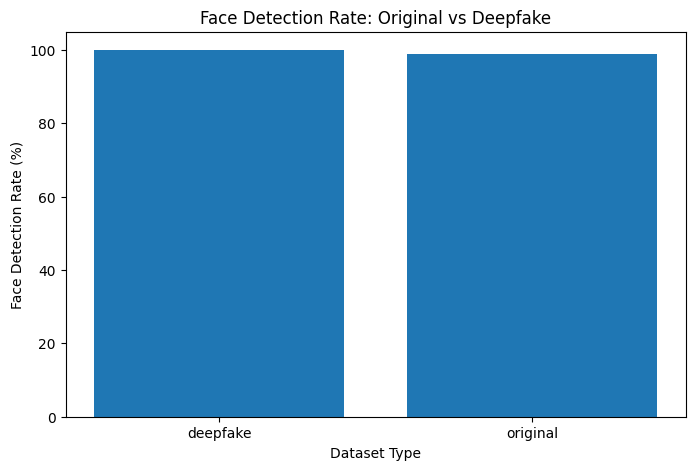

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary["label"],
    summary["average_detection_rate"]
)

plt.xlabel("Dataset Type")
plt.ylabel("Face Detection Rate (%)")
plt.title("Face Detection Rate: Original vs Deepfake")
plt.ylim(0, 105)

plt.show()

In [45]:
RESULTS_DIR = PROJECT_ROOT / "reports" / "lab_11"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_file = RESULTS_DIR / "face_detection_evaluation.csv"

results_df.to_csv(results_file, index=False)

print("Results saved to:")
print(results_file)

Results saved to:
/content/Deepfake-Detection-KYC/reports/lab_11/face_detection_evaluation.csv


In [46]:
summary_file = RESULTS_DIR / "face_detection_summary.csv"

summary.to_csv(summary_file, index=False)

print("Summary saved to:")
print(summary_file)

Summary saved to:
/content/Deepfake-Detection-KYC/reports/lab_11/face_detection_summary.csv


In [47]:
video_007 = original_dir / "007.mp4"

cap = cv2.VideoCapture(str(video_007))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_indices = np.linspace(
    0,
    total_frames - 1,
    5,
    dtype=int
)

failed_frames = []

for frame_idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

    success, frame = cap.read()

    if not success:
        failed_frames.append({
            "frame": int(frame_idx),
            "reason": "frame_read_failed"
        })
        continue

    faces = detect_faces(frame, detector)

    if len(faces) == 0:
        failed_frames.append({
            "frame": int(frame_idx),
            "reason": "no_face_detected"
        })

cap.release()

print("Failed frames:")
print(failed_frames)

Failed frames:
[{'frame': 504, 'reason': 'no_face_detected'}]


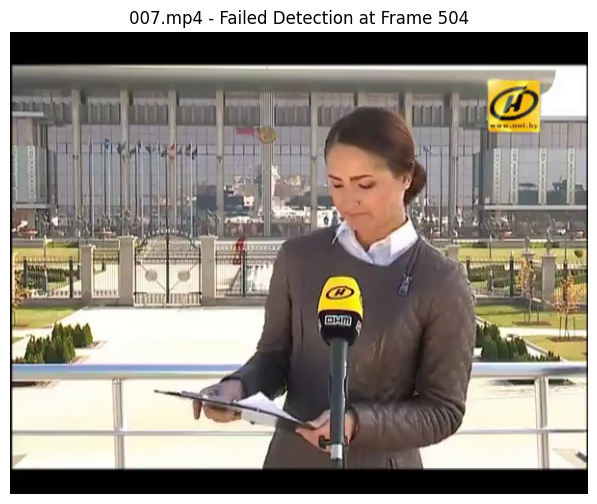

In [48]:
failed_frame_index = failed_frames[0]["frame"]

cap = cv2.VideoCapture(str(video_007))
cap.set(cv2.CAP_PROP_POS_FRAMES, failed_frame_index)

success, failed_frame = cap.read()

cap.release()

if success:
    rgb_frame = cv2.cvtColor(failed_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_frame)
    plt.title(f"007.mp4 - Failed Detection at Frame {failed_frame_index}")
    plt.axis("off")
    plt.show()

In [49]:
print(results_df)

          video  frames_checked  frames_with_faces  total_faces  \
0       000.mp4               5                  5            6   
1       001.mp4               5                  5            9   
2       002.mp4               5                  5            6   
3       003.mp4               5                  5            6   
4       004.mp4               5                  5           11   
5       005.mp4               5                  5            6   
6       006.mp4               5                  5            6   
7       007.mp4               5                  4            4   
8       008.mp4               5                  5            5   
9       009.mp4               5                  5            5   
10      010.mp4               5                  5           13   
11      011.mp4               5                  5           20   
12      012.mp4               5                  5            5   
13      013.mp4               5                  5            

In [51]:
print([name for name in globals() if "result" in name.lower() or "path" in name.lower()])

['Path', 'DATASET_PATH', 'sample_results', 'result', 'test_result', 'original_results', 'video_path', 'deepfake_results', 'all_results', 'results_df', 'RESULTS_DIR', 'results_file']


In [52]:
print("Results saved to:")
print(results_file)
print("File exists:", results_file.exists())

Results saved to:
/content/Deepfake-Detection-KYC/reports/lab_11/face_detection_evaluation.csv
File exists: True


In [53]:
print("Summary saved to:")
print(summary_file)
print("File exists:", summary_file.exists())

Summary saved to:
/content/Deepfake-Detection-KYC/reports/lab_11/face_detection_summary.csv
File exists: True


## Lab 11 Results

The Haar Cascade face detector was evaluated on:

- 20 original videos
- 20 deepfake videos
- 5 sampled frames per video
- 200 total sampled frames

### Results

| Dataset Type | Videos | Frames Checked | Frames With Faces | Average Detection Rate |
|--------------|--------|----------------|-------------------|------------------------|
| Deepfake | 20 | 100 | 100 | 100% |
| Original | 20 | 100 | 99 | 99% |

Overall, the detector successfully detected faces in 199 out of
200 sampled frames.

One missed detection was observed in:

- Video: `007.mp4`
- Frame: `504`
- Dataset type: Original

The face was visibly present in the frame, but the Haar Cascade
detector failed to detect it. This demonstrates that traditional
Haar Cascade detection may fail under challenging conditions such
as pose variation, relatively small face size, and background
complexity.

The evaluation shows that the detector performs well on the sampled
dataset, while also demonstrating the limitations of traditional
face detection methods.

### Observation: Missed Face Detection

During evaluation, one sampled frame from `007.mp4` was not detected
successfully by the Haar Cascade face detector.

- Video: `007.mp4`
- Frame: `504`
- Dataset type: Original
- Detection result: No face detected

Although the face is visibly present, the detector failed to identify it.
The failure may be attributed to factors such as the downward-facing pose,
relatively small face size, image quality, and background complexity.

This demonstrates that Haar Cascade detection is not perfectly reliable
for every frame, even when a human-visible face is present.

## Conclusion

In this lab, the face detection module developed in Lab 7 was
evaluated on a larger sample of FaceForensics++ videos.

The detector achieved a 100% average detection rate on the sampled
deepfake videos and a 99% average detection rate on the sampled
original videos.

The evaluation also identified a real failure case where a visible
face was not detected. This confirms that face detection should not
be assumed to be perfect and that detection failures should be
considered in later preprocessing stages.

The evaluation results have been saved for further analysis and
future integration with the deepfake detection pipeline.